In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display, HTML
from sklearn.decomposition import PCA

# cargar datos
DATA_PATH = "data/raw/monclova_lmp_mda_mtr_2024_2025.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

df["hora_dia"] = df["timestamp"].dt.hour
df["dia_semana"] = df["timestamp"].dt.day_name()

NODES = sorted(df["node_id"].unique())
PALETTE = plt.cm.tab10.colors
NODE_COLORS = {nodo: PALETTE[i % len(PALETTE)] for i, nodo in enumerate(NODES)}
DAYS_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


In [ ]:
def run_integrity_audit(data: pd.DataFrame) -> None:

    # Verificaciones de unicidad y completitud
    print("Verificaciones de unicidad y completitud:")
    dups = data.duplicated(subset=["process", "node_id", "timestamp"]).sum()
    nulls = data.isnull().sum().to_dict()
    print(f"Registros: {len(data):,} | Duplicados: {dups} | Valores nulos: {nulls}")

    # Verificacion de continuidad temporal
    expected_range = pd.date_range(start="2024-01-01 00:00:00", end="2025-06-30 23:00:00", freq="h")
    gaps = {
        f"{proc}_{node}": len(set(expected_range) - set(grp["timestamp"]))
        for (proc, node), grp in data.groupby(["process", "node_id"])
        if len(set(expected_range) - set(grp["timestamp"])) > 0
    }
    print("\nVerificacion de continuidad temporal:")
    print(f"Huecos temporales encontrados: {gaps}")

    # Verificacion de consistencia
    recon = data["pml_ene"] + data["pml_per"] + data["pml_cng"]
    res = (data["pml"] - recon).abs()
    print("\nVerificacion de consistencia:")
    print(f"(PML - (Ene + Per + Cng)): Residual maximo = {res.max():.6f}")

    # Valores negativos
    print("\nVerificacion de valores negativos:")
    for proc in ["MDA", "MTR"]:
        sub = data.loc[data["process"] == proc, "pml"]
        negs = (sub < 0).sum()
        print(f" Conteo de negativos para {proc}: {negs} ({negs / len(sub):.2%})")

        # Verificacion de valores en cero (pml, pml_ene, pml_per, pml_cng == 0.0 simultaneamente)
    zero_mask = (
        (data["pml"] == 0) &
        (data["pml_ene"] == 0) &
        (data["pml_per"] == 0) &
        (data["pml_cng"] == 0)
    )
    zero_flagged = data.loc[zero_mask, ["process", "node_id", "timestamp"]]
    print("\nVerificacion de valores en cero:")
    print(f"(Las 4 columnas de precio == 0.0 simultaneamente): {len(zero_flagged)} filas marcadas.")


run_integrity_audit(df)

Uniqueness & Completeness Checks:
Records: 236,304 | Duplicates : 0 | Null values: {'process': 0, 'node_id': 0, 'fecha': 0, 'hora': 0, 'pml': 0, 'pml_ene': 0, 'pml_per': 0, 'pml_cng': 0, 'timestamp': 0, 'hora_dia': 0, 'dia_semana': 0}

Temporal Continuity Check:
Temporal gaps found: {}

Consistency check:
(PML - (Ene + Per + Cng)): Max Residual = 0.020000

Negative values Check:
 Negative Count for MDA: 45 (0.04%)
 Negative Count for MTR: 0 (0.00%)

Repeated values  Check:
(Persistent Flatlines >= 4h): 9 instances flagged.
    MDA @ 06AEO-115 (14), MDA @ 06AHM-400 (14), MDA @ 06FRO-115 (14), MDA @ 06GRA-115 (14), MDA @ 06MON-115 (14), MDA @ 06MON-230 (14), MDA @ 06RGS-115 (14), MDA @ 06TKS-115 (14), MDA @ 06XOC-115 (14)


DISTRIBUTION METRICS SUMMARY
Process                          MDA          MTR
Observations                  118152       118152
Mean                      784.435594   813.365927
Std. Deviation           1060.391936   965.228159
Median (P50)                 534.405       541.03
IQR (P75 - P25)              387.975     438.1825
Minimum (P0)                  -53.87        20.96
Percentile 1 (P1)           151.0751     202.7451
Percentile 5 (P5)           251.2055     258.5955
Percentile 95 (P95)        2067.0445    2205.5325
Percentile 99 (P99)        5618.9933    5376.2847
Percentile 99.9 (P99.9)  12423.52658  10922.49936
Maximum (P100)              26222.27     12942.84
Skewness                      7.4567     5.621522
Kurtosis                   82.831793     43.64675


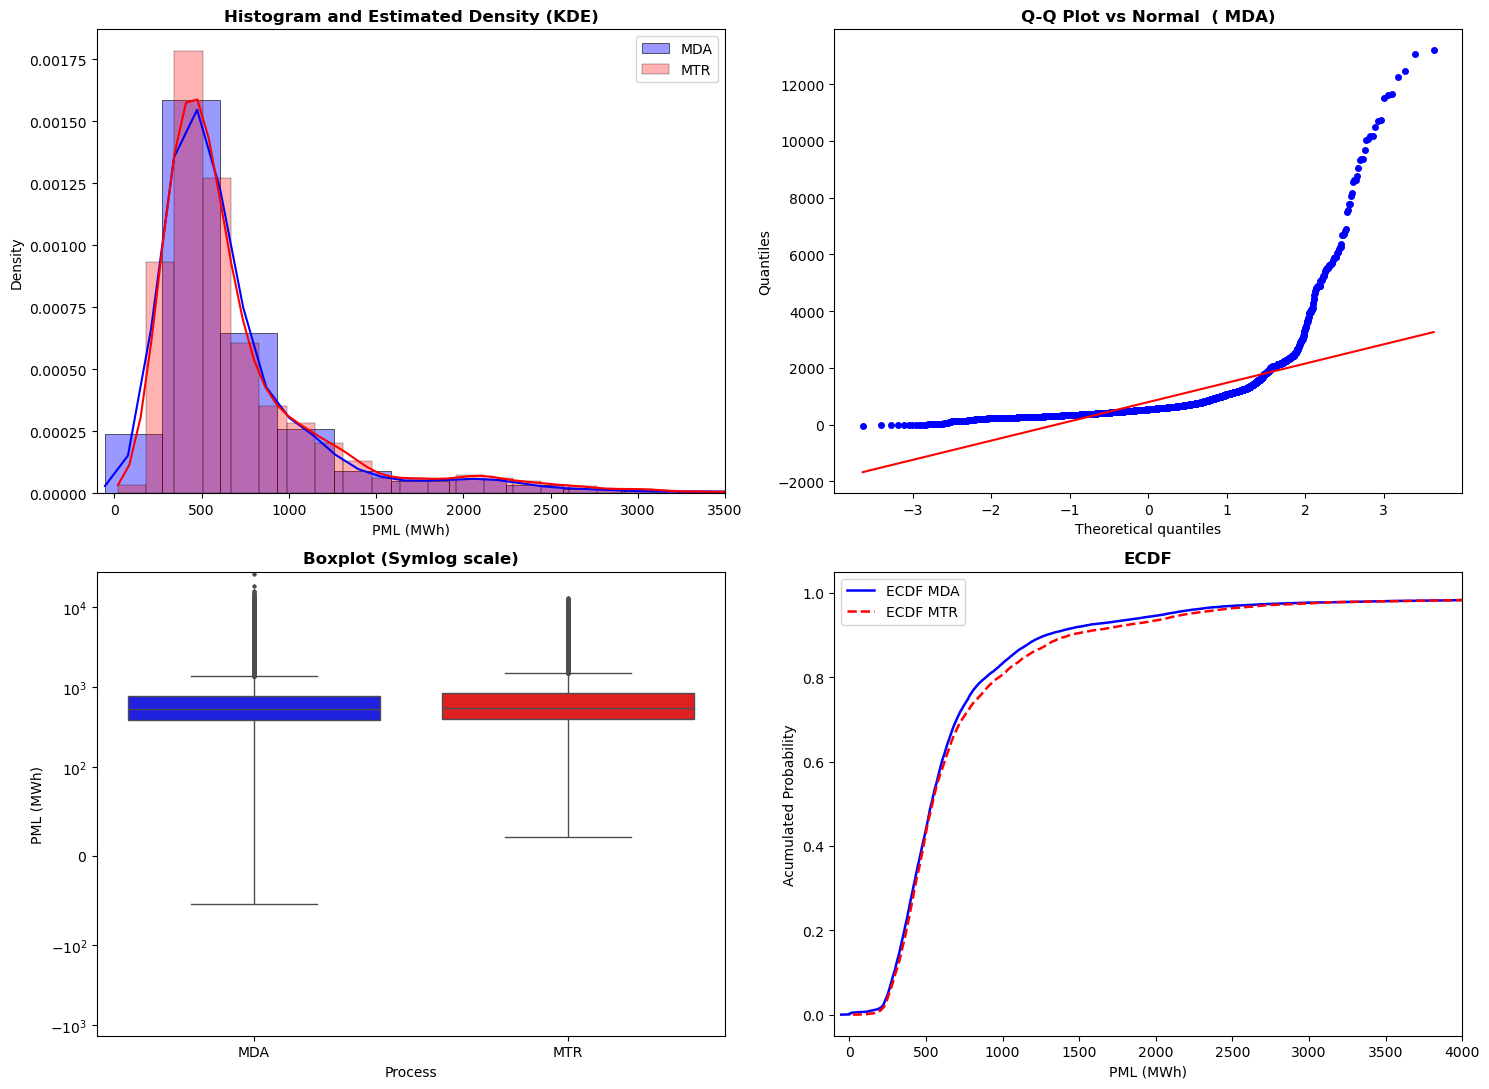

In [ ]:
def compute_distribution_metrics(series: pd.Series, name: str) -> dict:
    return {
        "Proceso": name,
        "Observaciones": len(series),
        "Media": series.mean(),
        "Desviacion estandar": series.std(),
        "Mediana (P50)": series.median(),
        "IQR (P75 - P25)": series.quantile(0.75) - series.quantile(0.25),
        "Minimo (P0)": series.min(),
        "Percentil 1 (P1)": series.quantile(0.01),
        "Percentil 5 (P5)": series.quantile(0.05),
        "Percentil 95 (P95)": series.quantile(0.95),
        "Percentil 99 (P99)": series.quantile(0.99),
        "Percentil 99.9 (P99.9)": series.quantile(0.999),
        "Maximo (P100)": series.max(),
        "Sesgo (Skewness)": stats.skew(series),
        "Curtosis (Kurtosis)": stats.kurtosis(series),
    }

mda_pml = df[df["process"] == "MDA"]["pml"]
mtr_pml = df[df["process"] == "MTR"]["pml"]

dist_df = pd.DataFrame([
    compute_distribution_metrics(mda_pml, "MDA"),
    compute_distribution_metrics(mtr_pml, "MTR")
]).T

print("=" * 80)
print("RESUMEN DE METRICAS DE DISTRIBUCION")
print("=" * 80)
print(dist_df.to_string(header=False))


fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Histograma y KDE
sns.histplot(mda_pml, bins=80, kde=True, stat="density", color="blue", label="MDA", alpha=0.4, ax=axes[0, 0])
sns.histplot(mtr_pml, bins=80, kde=True, stat="density", color="red", label="MTR", alpha=0.3, ax=axes[0, 0])
axes[0, 0].set_xlim(-100, 3500)
axes[0, 0].set_title("Histograma y Densidad Estimada (KDE)", fontweight="bold")
axes[0, 0].set_xlabel("PML (MWh)")
axes[0, 0].legend()

# Q-Q Plot
sample_mda = np.random.choice(mda_pml, size=5000, replace=False)
stats.probplot(sample_mda, dist="norm", plot=axes[0, 1])
axes[0, 1].get_lines()[0].set_markerfacecolor("blue")
axes[0, 1].get_lines()[0].set_markersize(4.0)
axes[0, 1].set_title("Q-Q Plot vs Normal (MDA)", fontweight="bold")
axes[0, 1].set_ylabel("Cuantiles")

# Boxplot
plot_df = pd.DataFrame({
    "PML": np.concatenate([mda_pml, mtr_pml]),
    "Process": ["MDA"] * len(mda_pml) + ["MTR"] * len(mtr_pml)
})
sns.boxplot(
    data=plot_df, x="Process", y="PML", hue="Process", 
    palette=["blue", "red"], ax=axes[1, 0], fliersize=1.5, legend=False
)
axes[1, 0].set_yscale("symlog", linthresh=100)
axes[1, 0].set_title("Boxplot (escala Symlog)", fontweight="bold")
axes[1, 0].set_ylabel("PML (MWh)")

# ECDF
for series, color, label, ls in [(mda_pml, "blue", "ECDF MDA", "-"), (mtr_pml, "red", "ECDF MTR", "--")]:
    sorted_vals = np.sort(series)
    prob = np.arange(len(sorted_vals)) / float(len(sorted_vals))
    axes[1, 1].plot(sorted_vals, prob, label=label, color=color, lw=1.8, linestyle=ls)

axes[1, 1].set_xlim(-100, 4000)
axes[1, 1].set_title("ECDF", fontweight="bold")
axes[1, 1].set_xlabel("PML (MWh)")
axes[1, 1].set_ylabel("Probabilidad Acumulada")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

,pml,pml_ene,pml_per,pml_cng
count,118152.000000,118152.000000,118152.000000,118152.000000
mean,784.435594,844.497173,-48.770860,-11.291345
std,1060.391936,1069.081389,49.487748,180.437936
min,-53.870000,-0.010000,-603.850000,-2612.110000
25%,387.497500,421.010000,-64.010000,-25.220000
50%,534.405000,577.570000,-39.790000,-3.120000
75%,775.472500,867.355000,-22.310000,19.500000
max,26222.270000,25590.570000,805.440000,3717.140000


,pml,pml_ene,pml_per,pml_cng
count,118152.000000,118152.000000,118152.000000,118152.000000
mean,813.365927,864.837835,-48.150923,-3.321546
std,965.228159,984.074417,54.280883,130.491462
min,20.960000,-0.010000,-717.060000,-2889.960000
25%,399.140000,428.570000,-62.430000,-23.812500
50%,541.030000,579.195000,-37.930000,-1.900000
75%,837.322500,926.962500,-19.480000,12.302500
max,12942.840000,12834.830000,203.150000,1799.030000


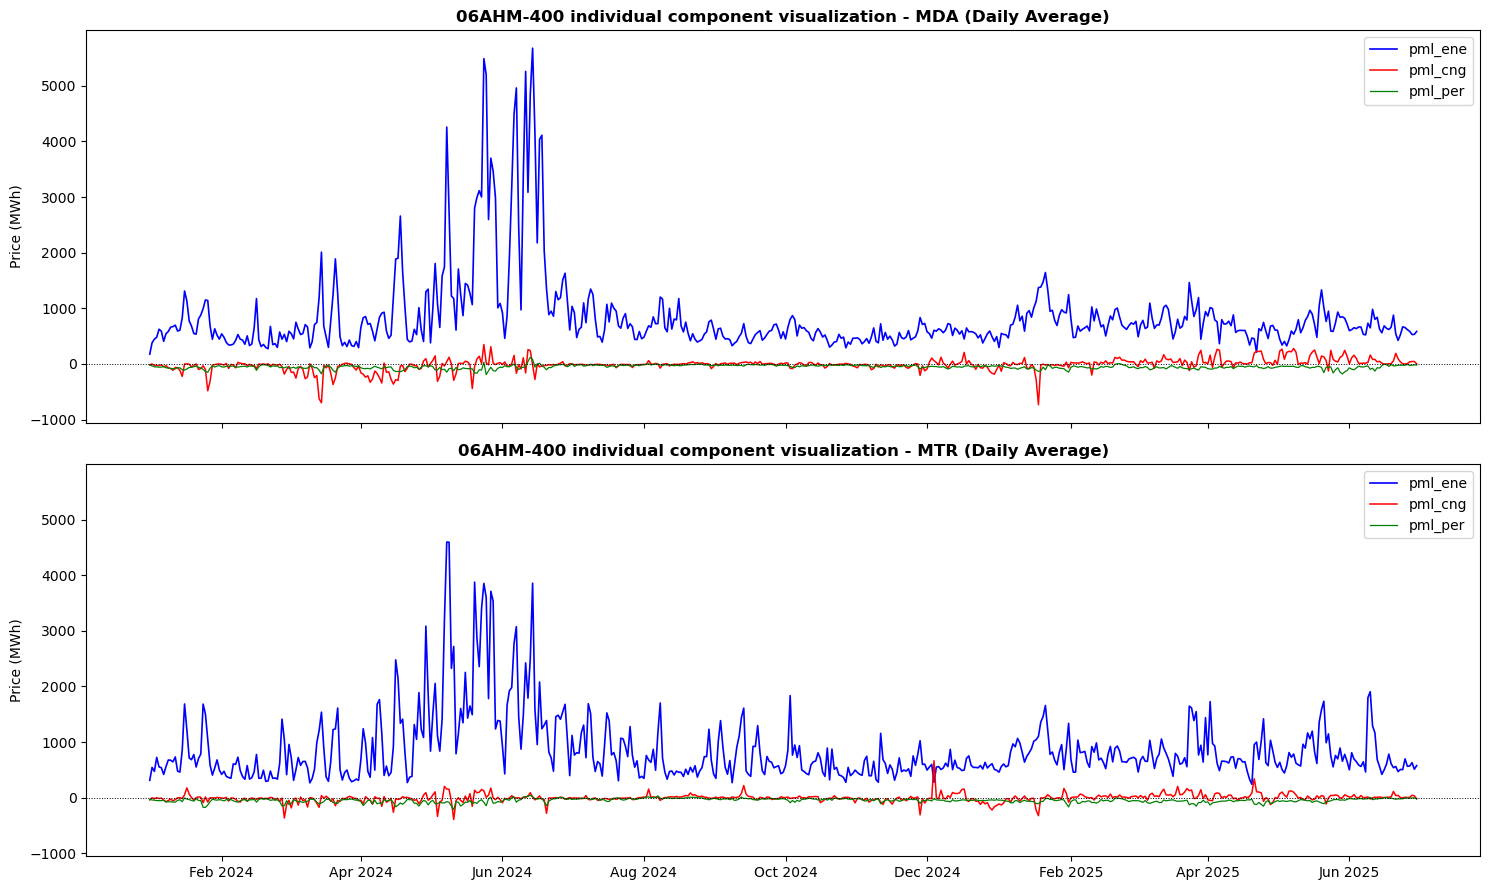

In [ ]:
# Visualizacion del resumen de datos
cols_to_drop = ["hora", "hora_dia", "timestamp"]
desc_mda = df[df["process"] == "MDA"].drop(columns=cols_to_drop, errors="ignore").describe()
desc_mtr = df[df["process"] == "MTR"].drop(columns=cols_to_drop, errors="ignore").describe()

display(HTML("Resumen MDA"))
display(desc_mda)
display(HTML("Resumen MTR"))
display(desc_mtr)

# 2. Grafica de descomposicion de componentes, doble mercado
target_node = "06AHM-400"
components = ["pml_ene", "pml_per", "pml_cng"]

mda_daily = df[(df["process"] == "MDA") & (df["node_id"] == target_node)].set_index("timestamp").resample("D")[components].mean()
mtr_daily = df[(df["process"] == "MTR") & (df["node_id"] == target_node)].set_index("timestamp").resample("D")[components].mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, sharey=True)
market_series = [(mda_daily, axes[0], "MDA"), (mtr_daily, axes[1], "MTR")]

for data, ax, title in market_series:
    ax.plot(data.index, data["pml_ene"], label="pml_ene", color="blue", lw=1.2)
    ax.plot(data.index, data["pml_cng"], label="pml_cng", color="red", lw=1.1)
    ax.plot(data.index, data["pml_per"], label="pml_per", color="green", lw=0.9)
    ax.axhline(0, color="black", lw=0.7, linestyle=":")
    ax.set_title(f"{target_node} visualizacion de componentes individuales - {title} (Promedio diario)", fontweight="bold")
    ax.set_ylabel("Precio (MWh)")
    ax.legend(loc="upper right")

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.show()

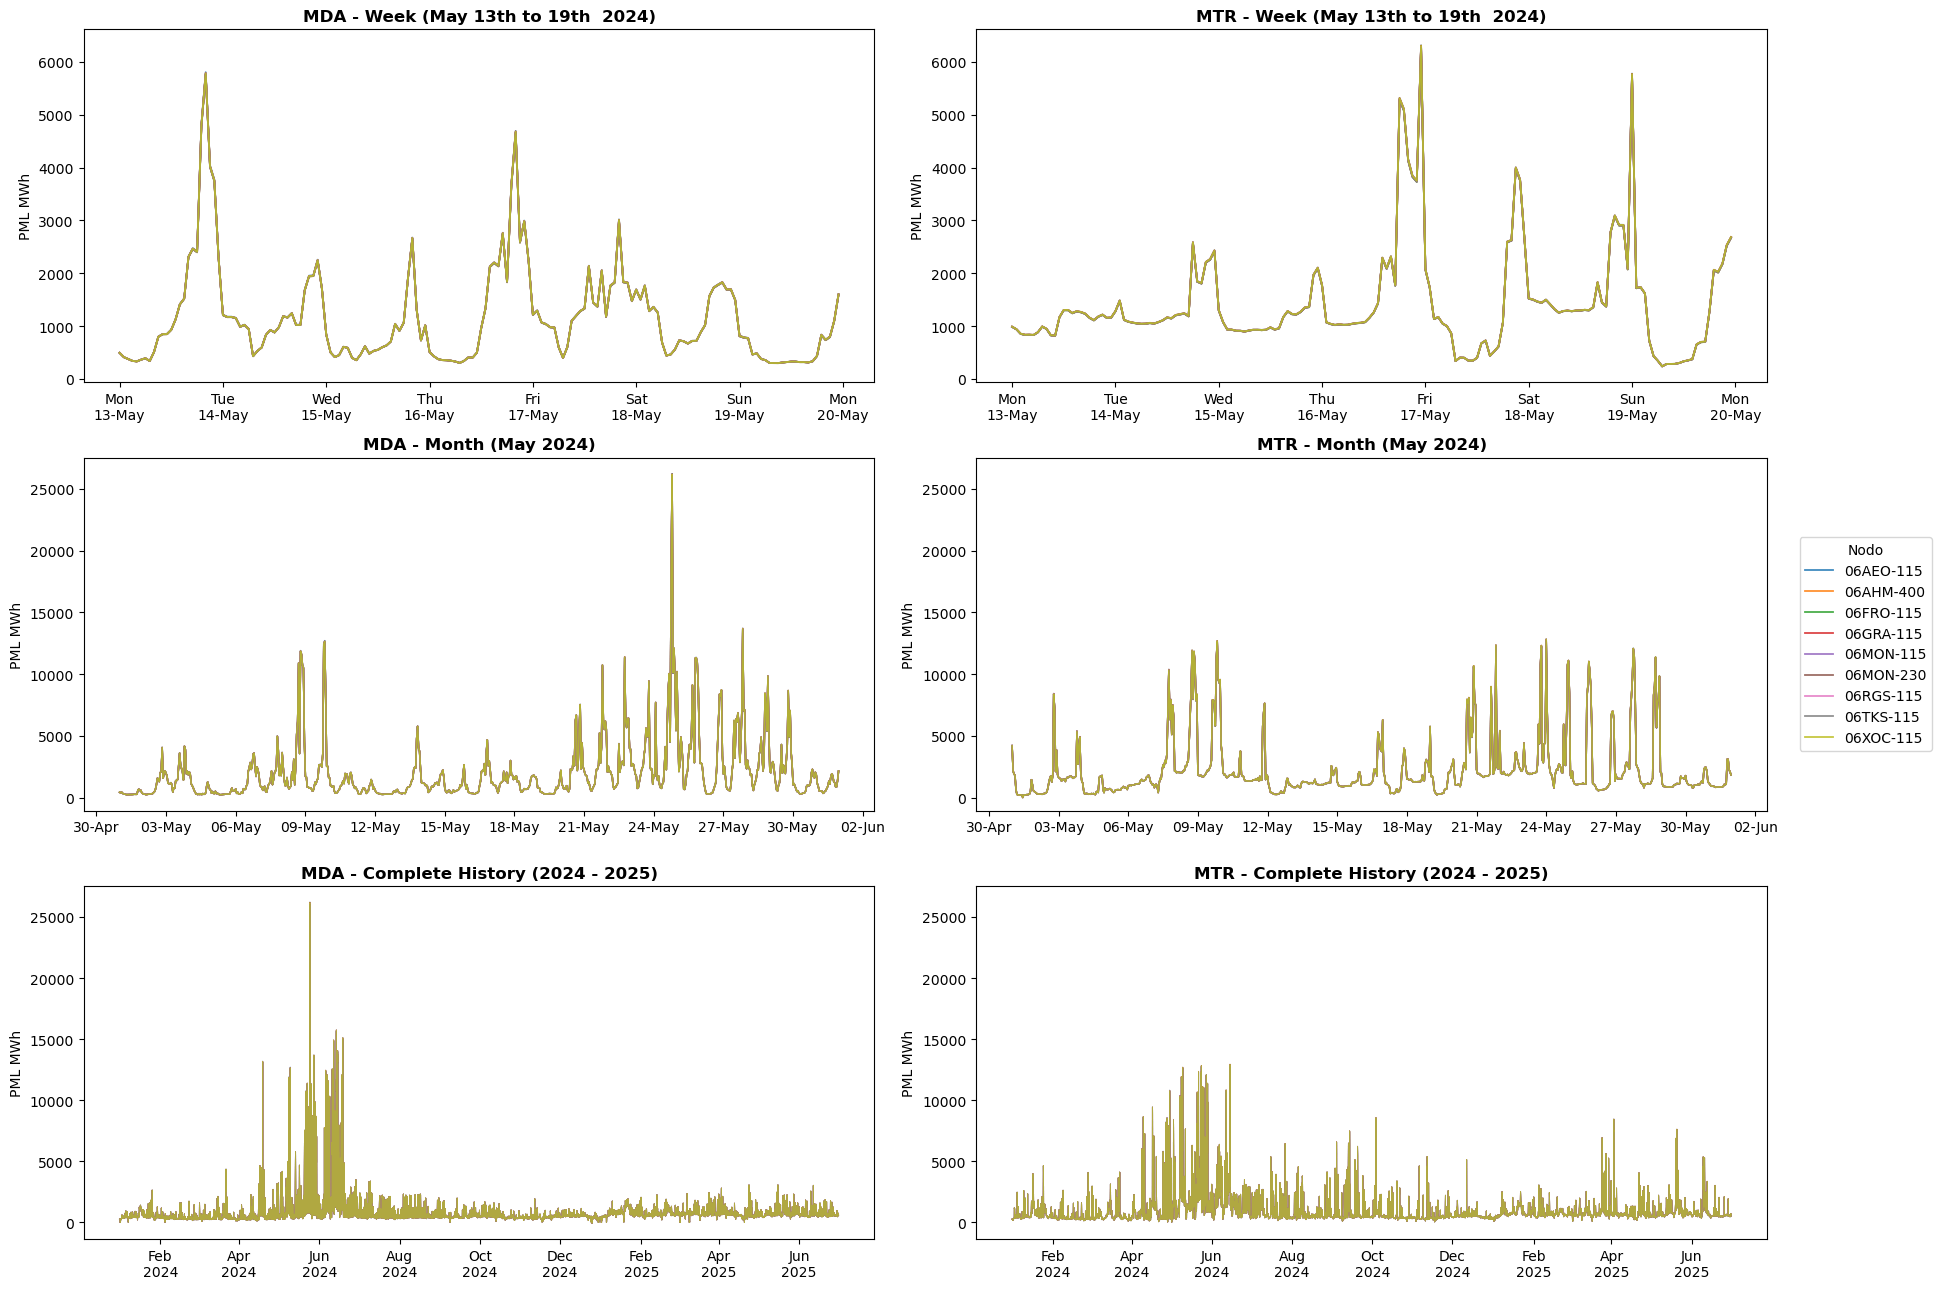

In [ ]:
# Visualizacion general de la serie de tiempo
horizontes = [
    {"title": "Semana (13 al 19 de mayo 2024)", "start": "2024-05-13", "end": "2024-05-19 23:00", 
     "loc": mdates.DayLocator(), "fmt": "%a\n%d-%b", "lw": 1.3, "alpha": 0.85},
    {"title": "Mes (mayo 2024)", "start": "2024-05-01", "end": "2024-05-31 23:00", 
     "loc": mdates.DayLocator(interval=3), "fmt": "%d-%b", "lw": 1.1, "alpha": 0.80},
    {"title": "Historico completo (2024 - 2025)", "start": None, "end": None, 
     "loc": mdates.MonthLocator(interval=2), "fmt": "%b\n%Y", "lw": 0.7, "alpha": 0.70}
]
fig, axes = plt.subplots(3, 2, figsize=(18, 13))
for r_idx, h in enumerate(horizontes):
    df_sub = df[(df["timestamp"] >= h["start"]) & (df["timestamp"] <= h["end"])] if h["start"] else df
    for c_idx, proc in enumerate(["MDA", "MTR"]):
        ax = axes[r_idx, c_idx]
        df_proc = df_sub[df_sub["process"] == proc]
        
        for nodo in NODES:
            sub = df_proc[df_proc["node_id"] == nodo].sort_values("timestamp")
            ax.plot(sub["timestamp"], sub["pml"], label=nodo, color=NODE_COLORS[nodo], lw=h["lw"], alpha=h["alpha"])
        
        ax.set_title(f"{proc} - {h['title']}", fontweight="bold")
        ax.set_ylabel("PML MWh")
        ax.xaxis.set_major_locator(h["loc"])
        ax.xaxis.set_major_formatter(mdates.DateFormatter(h["fmt"]))
    y_min = min(axes[r_idx, 0].get_ylim()[0], axes[r_idx, 1].get_ylim()[0])
    y_max = max(axes[r_idx, 0].get_ylim()[1], axes[r_idx, 1].get_ylim()[1])
    axes[r_idx, 0].set_ylim(y_min, y_max)
    axes[r_idx, 1].set_ylim(y_min, y_max)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.08, 0.5), title="Nodo", frameon=True)
plt.tight_layout()
plt.show()

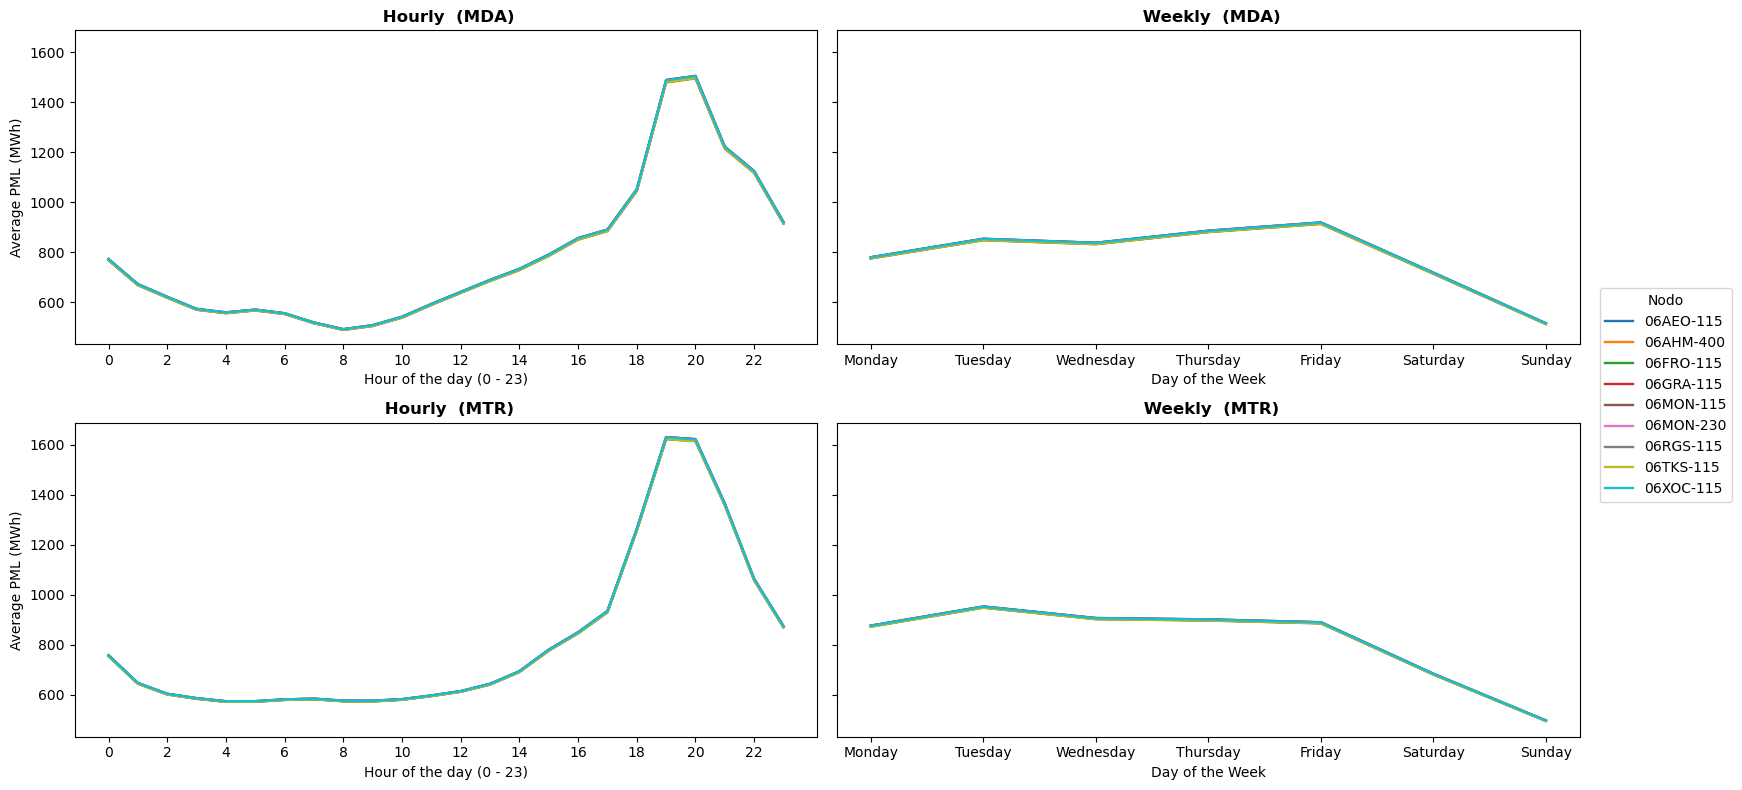

Correlation between nodes (MDA process)
- Minimum correlation: 1.0000 - Average correlation:  1.0000


In [ ]:
# Curvas diarias y semanales (MDA vs. MTR)
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharey=True)
for r_idx, proc in enumerate(["MDA", "MTR"]):
    df_p = df[df["process"] == proc]
    
    # Perfil horario
    diurnal = df_p.groupby(["hora_dia", "node_id"])["pml"].mean().unstack()
    diurnal.plot(ax=axes[r_idx, 0], lw=1.7, colormap="tab10", legend=False)
    axes[r_idx, 0].set_title(f" Horario ({proc})", fontweight="bold")
    axes[r_idx, 0].set_xlabel("Hora del dia (0 - 23)")
    axes[r_idx, 0].set_ylabel("PML promedio (MWh)")
    axes[r_idx, 0].set_xticks(range(0, 24, 2))
    # Perfil semanal
    weekly = df_p.groupby(["dia_semana", "node_id"])["pml"].mean().unstack().reindex(DAYS_ORDER)
    weekly.plot(ax=axes[r_idx, 1], lw=1.7, colormap="tab10", legend=False)
    axes[r_idx, 1].set_title(f" Semanal ({proc})", fontweight="bold")
    axes[r_idx, 1].set_xlabel("Dia de la semana")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", bbox_to_anchor=(1.09, 0.5), title="Nodo", frameon=True)
plt.tight_layout()
plt.show()
# Correlacion entre nodos (proceso MDA)
pml_pivot = df[df["process"] == "MDA"].pivot(index="timestamp", columns="node_id", values="pml")
print("=" * 80)
print("Correlacion entre nodos (proceso MDA)")
print("=" * 80)
corr_vals = pml_pivot.corr().values[np.triu_indices(len(NODES), k=1)]
print(f"- Correlacion minima: {corr_vals.min():.4f} - Correlacion promedio: {corr_vals.mean():.4f}")

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf

# 1. Definir horizonte de rezagos y lags clave para forecasting
max_lags = 168  # 1 semana completa (7 días * 24 horas)
key_lags = [1, 2, 3, 24, 48, 72, 168]

acf_records = []
pacf_records = []

# 2. Calcular ACF y PACF para cada uno de los 9 nodos en MDA
for node in NODES:
    node_series = df.loc[
        (df["process"] == "MDA") & (df["node_id"] == node)
    ].sort_values("timestamp")["pml"].values
    
    # Cálculo vectorizado con statsmodels
    node_acf = acf(node_series, nlags=max_lags, fft=True)
    node_pacf = pacf(node_series, nlags=max_lags, method="ywm")
    
    # Extraer lags críticos
    acf_records.append({f"Lag_{lag}": node_acf[lag] for lag in key_lags} | {"node_id": node})
    pacf_records.append({f"Lag_{lag}": node_pacf[lag] for lag in key_lags} | {"node_id": node})

# Consolidar en DataFrames comparativos
df_acf_summary = pd.DataFrame(acf_records).set_index("node_id")
df_pacf_summary = pd.DataFrame(pacf_records).set_index("node_id")

print("=" * 90)
print("ACF (AUTOCORRELACIÓN TOTAL) - PERSISTENCIA TEMPORAL (MDA)")
print("=" * 90)
print(df_acf_summary.round(4).to_string())

print("\n" + "=" * 90)
print("PACF (AUTOCORRELACIÓN PARCIAL) - IMPACTO DIRECTO AISLADO (MDA)")
print("=" * 90)
print(df_pacf_summary.round(4).to_string())

ACF (AUTOCORRELACIÓN TOTAL) - PERSISTENCIA TEMPORAL (MDA)
            Lag_1   Lag_2   Lag_3  Lag_24  Lag_48  Lag_72  Lag_168
node_id                                                           
06AEO-115  0.8411  0.7282  0.6612  0.6773  0.5617  0.5383   0.4417
06AHM-400  0.8411  0.7281  0.6610  0.6772  0.5616  0.5381   0.4414
06FRO-115  0.8411  0.7281  0.6610  0.6772  0.5617  0.5382   0.4415
06GRA-115  0.8411  0.7282  0.6611  0.6774  0.5619  0.5384   0.4417
06MON-115  0.8411  0.7282  0.6611  0.6772  0.5617  0.5381   0.4415
06MON-230  0.8411  0.7282  0.6611  0.6772  0.5617  0.5381   0.4415
06RGS-115  0.8411  0.7282  0.6610  0.6773  0.5618  0.5383   0.4416
06TKS-115  0.8411  0.7281  0.6610  0.6772  0.5617  0.5382   0.4415
06XOC-115  0.8411  0.7283  0.6612  0.6774  0.5620  0.5384   0.4418

PACF (AUTOCORRELACIÓN PARCIAL) - IMPACTO DIRECTO AISLADO (MDA)
            Lag_1   Lag_2   Lag_3  Lag_24  Lag_48  Lag_72  Lag_168
node_id                                                           
06AEO-1

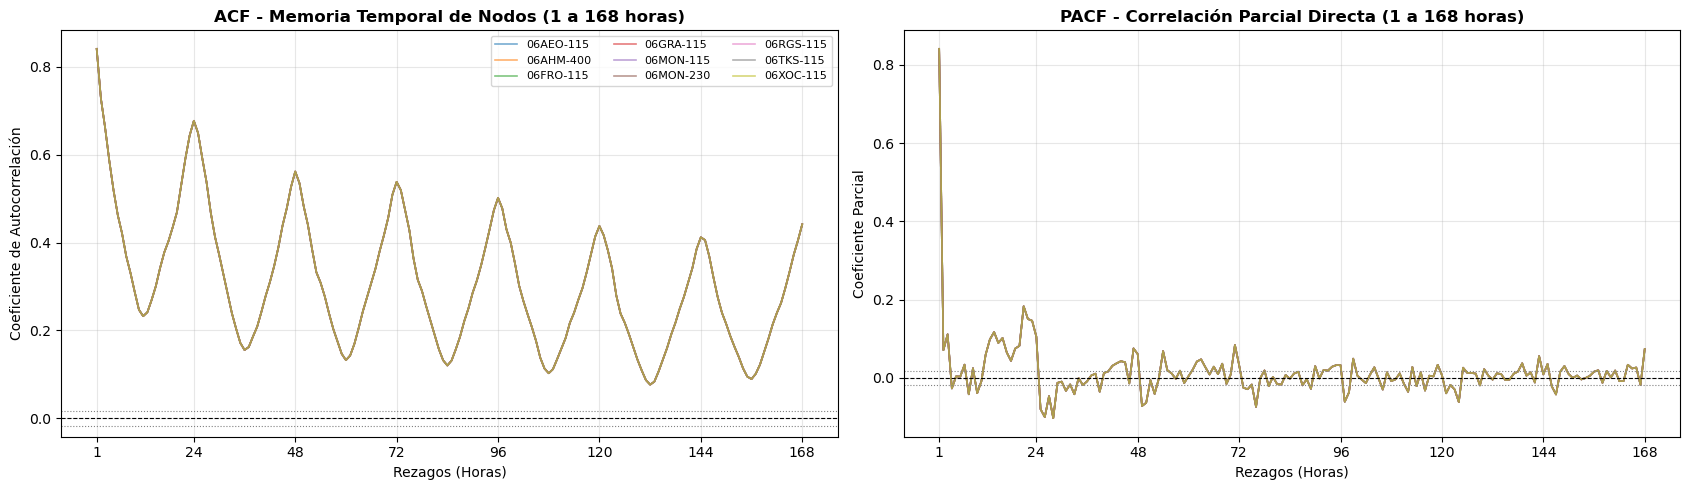

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5), sharey=False)

# Umbral de significancia estadística asintótica (95% IC)
n_obs = len(df.loc[(df["process"] == "MDA") & (df["node_id"] == NODES[0])])
conf_interval = 1.96 / np.sqrt(n_obs)

for node in NODES:
    node_series = df.loc[
        (df["process"] == "MDA") & (df["node_id"] == node)
    ].sort_values("timestamp")["pml"].values
    
    node_acf = acf(node_series, nlags=max_lags, fft=True)
    node_pacf = pacf(node_series, nlags=max_lags, method="ywm")
    
    color = NODE_COLORS[node]
    axes[0].plot(range(1, max_lags + 1), node_acf[1:], label=node, color=color, alpha=0.6, lw=1.2)
    axes[1].plot(range(1, max_lags + 1), node_pacf[1:], label=node, color=color, alpha=0.6, lw=1.2)

# Configuración gráfica de ACF
axes[0].axhline(0, color="black", lw=0.8, linestyle="--")
axes[0].axhline(conf_interval, color="gray", lw=0.8, linestyle=":")
axes[0].axhline(-conf_interval, color="gray", lw=0.8, linestyle=":")
axes[0].set_title("ACF - Memoria Temporal de Nodos (1 a 168 horas)", fontweight="bold")
axes[0].set_xlabel("Rezagos (Horas)")
axes[0].set_ylabel("Coeficiente de Autocorrelación")
axes[0].set_xticks([1, 24, 48, 72, 96, 120, 144, 168])
axes[0].grid(True, alpha=0.3)

# Configuración gráfica de PACF
axes[1].axhline(0, color="black", lw=0.8, linestyle="--")
axes[1].axhline(conf_interval, color="gray", lw=0.8, linestyle=":")
axes[1].axhline(-conf_interval, color="gray", lw=0.8, linestyle=":")
axes[1].set_title("PACF - Correlación Parcial Directa (1 a 168 horas)", fontweight="bold")
axes[1].set_xlabel("Rezagos (Horas)")
axes[1].set_ylabel("Coeficiente Parcial")
axes[1].set_xticks([1, 24, 48, 72, 96, 120, 144, 168])
axes[1].grid(True, alpha=0.3)

# Leyenda unificada
axes[0].legend(loc="upper right", fontsize=8, ncol=3, frameon=True)
plt.tight_layout()
plt.show()

### Análisis estacionalidad (uso de datos procesados)

In [2]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
import os
import pandas as pd

RAW_PATH = "data/processed/monclova_lmp_mda_mtr_2024_2025_clean.csv"
PROCESSED_DIR = "data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

df_clean = pd.read_csv(RAW_PATH, parse_dates=["timestamp"])
print(f"Filas cargadas: {len(df_clean):,}")
df_clean.head()

warnings.filterwarnings("ignore")


def _adf_p(series):
    return adfuller(series, autolag="AIC")[1]


def _kpss_p(series, regression="c"):
    try:
        return kpss(series, regression=regression, nlags="auto")[1]
    except Exception:
        return float("nan")


stationarity_results = []
for process in ["MDA", "MTR"]:
    for node, g in df_clean[df_clean["process"] == process].groupby("node_id"):
        s = g.sort_values("timestamp")["pml"]
        stationarity_results.append({
            "process": process,
            "node": node,
            "adf_p_level": _adf_p(s.values),
            "kpss_p_level_c": _kpss_p(s.values, "c"),
            "kpss_p_level_ct": _kpss_p(s.values, "ct"),
            "adf_p_seasonal24": _adf_p(s.diff(24).dropna().values),
            "kpss_p_seasonal24": _kpss_p(s.diff(24).dropna().values),
            "adf_p_seasonal168": _adf_p(s.diff(168).dropna().values),
            "kpss_p_seasonal168": _kpss_p(s.diff(168).dropna().values),
        })

stationarity_df = pd.DataFrame(stationarity_results)
pd.set_option("display.width", 200)
print(stationarity_df.to_string(index=False))

stationarity_df.to_csv(os.path.join(PROCESSED_DIR, "stationarity_tests_summary.csv"), index=False)

Filas cargadas: 236,304
process      node  adf_p_level  kpss_p_level_c  kpss_p_level_ct  adf_p_seasonal24  kpss_p_seasonal24  adf_p_seasonal168  kpss_p_seasonal168
    MDA 06AEO-115 1.029569e-12            0.01             0.01               0.0                0.1       2.499333e-18                 0.1
    MDA 06AHM-400 1.028696e-12            0.01             0.01               0.0                0.1       2.494048e-18                 0.1
    MDA 06FRO-115 1.031890e-12            0.01             0.01               0.0                0.1       2.506051e-18                 0.1
    MDA 06GRA-115 1.035247e-12            0.01             0.01               0.0                0.1       2.513153e-18                 0.1
    MDA 06MON-115 1.034439e-12            0.01             0.01               0.0                0.1       2.501460e-18                 0.1
    MDA 06MON-230 1.032078e-12            0.01             0.01               0.0                0.1       2.499684e-18                 